In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# bs_e3 = pd.read_csv('10e3/BS_E_e3')
# bs_e4 = pd.read_csv('10e4/BS_E_e4')
# bs_e5 = pd.read_csv('10e5/BS_E_e5')

bs_e3 = pd.read_csv('10e3/BS_E_e3', sep='\t|\s+', engine='python', skiprows=2, header=None)
bs_e3.columns = ['Energy (keV)', 'Hits (Normalized)']

bs_e4 = pd.read_csv('10e4/BS_E_e4', sep='\t|\s+', engine='python', skiprows=2, header=None)
bs_e4.columns = ['Energy (keV)', 'Hits (Normalized)']

bs_e5 = pd.read_csv('10e5/BS_E_e5', sep='\t|\s+', engine='python', skiprows=2, header=None)
bs_e5.columns = ['Energy (keV)', 'Hits (Normalized)']

print(bs_e3.shape)

(300, 2)


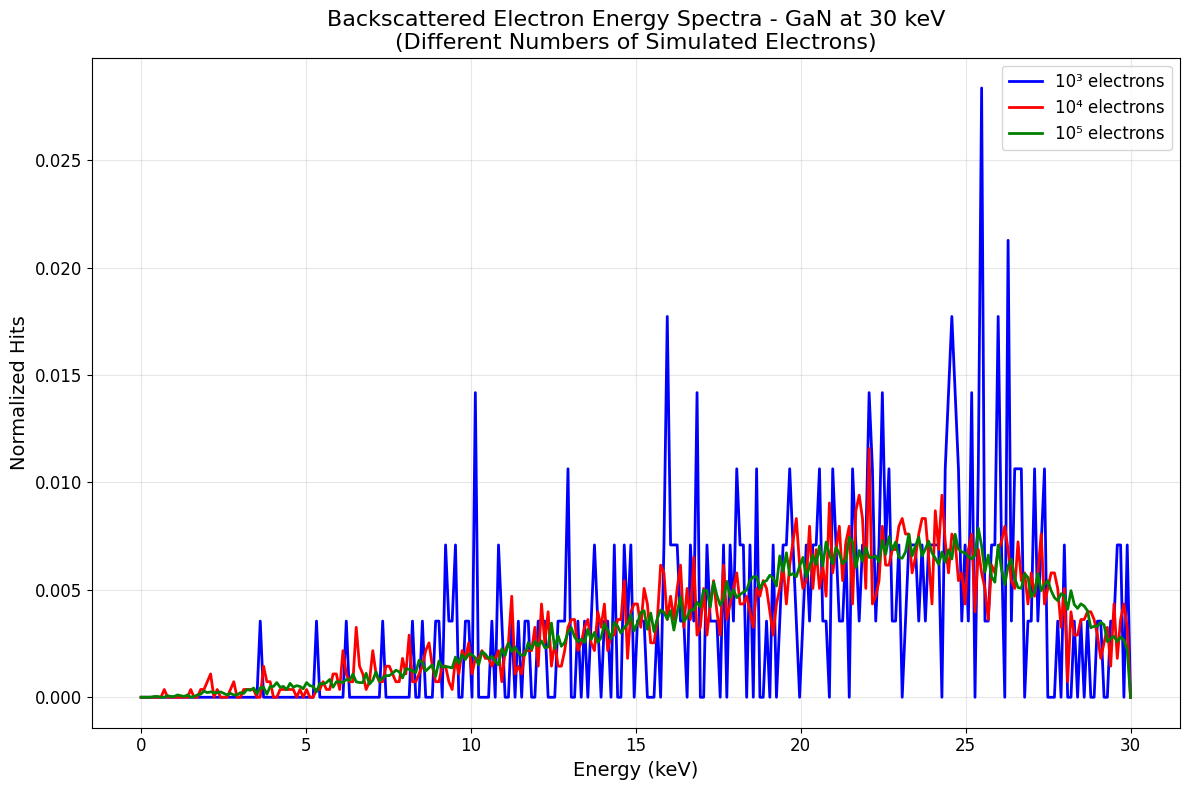

In [77]:
# Create the plot for all three spectra
plt.figure(figsize=(12, 8))

# Plot all three datasets with different styles for clarity
plt.plot(bs_e3['Energy (keV)'], bs_e3['Hits (Normalized)'], 
         label='10³ electrons', linewidth=2, color='blue')
plt.plot(bs_e4['Energy (keV)'], bs_e4['Hits (Normalized)'], 
         label='10⁴ electrons', linewidth=2, color='red')
plt.plot(bs_e5['Energy (keV)'], bs_e5['Hits (Normalized)'], 
         label='10⁵ electrons', linewidth=2, color='green')

# Professional formatting (important for your assignment!)
plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Normalized Hits', fontsize=14)
plt.title('Backscattered Electron Energy Spectra - GaN at 30 keV\n(Different Numbers of Simulated Electrons)', 
          fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=12)

# Make it look professional
plt.tight_layout()
plt.show()

# Optional: Save the figure
# plt.savefig('BS_Energy_Spectra_Comparison.png', dpi=300, bbox_inches='tight')

Why the 3 spectra are not identical:

Statistical noise: With fewer electrons (10³), you get more statistical fluctuations
Monte Carlo uncertainty: Each simulation uses random sampling
Smoothness: Higher electron counts (10⁵) give smoother, more reliable curves
Peak definition: Low statistics may miss or poorly define spectral features

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import integrate

# Prepare the data
x_data = bs_e5['Energy (keV)'].values
y_data = bs_e5['Hits (Normalized)'].values

# Define all our fitting functions
def exponential_func(x, a, b, c):
    """Exponential decay: a * exp(-b*x) + c"""
    return a * np.exp(-b * x) + c

def gaussian_func(x, a, b, c, d):
    """Gaussian: a * exp(-((x-b)/c)^2) + d"""
    return a * np.exp(-((x - b) / c)**2) + d

def power_law_func(x, a, b, c):
    """Power law: a * (x+1)^(-b) + c"""
    return a * (x + 1)**(-b) + c

def linear_func(x, a, b):
    """Linear: a*x + b"""
    return a * x + b

def quadratic_func(x, a, b, c):
    """Quadratic: a*x^2 + b*x + c"""
    return a * x**2 + b * x + c

# Store all functions and their names
functions = {
    'Exponential': exponential_func,
    'Gaussian': gaussian_func, 
    'Power Law': power_law_func,
    'Linear': linear_func,
    'Quadratic': quadratic_func
}

# Try fitting each function
fit_results = {}
fit_errors = {}

print("Attempting to fit all functions...")
print("="*50)

for name, func in functions.items():
    try:
        # Different initial guesses for different functions
        if name == 'Exponential':
            p0 = [0.01, 0.1, 0.001]
        elif name == 'Gaussian':
            p0 = [0.01, 15, 5, 0.001]  # peak at ~15 keV
        elif name == 'Power Law':
            p0 = [0.1, 1, 0.001]
        elif name == 'Linear':
            p0 = [0.0001, 0.001]
        elif name == 'Quadratic':
            p0 = [1e-6, 0.0001, 0.001]
            
        # Perform the fit
        popt, pcov = curve_fit(func, x_data, y_data, p0=p0, maxfev=5000)
        
        # Calculate R-squared
        y_pred = func(x_data, *popt)
        ss_res = np.sum((y_data - y_pred) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Store results
        fit_results[name] = {'params': popt, 'r_squared': r_squared, 'y_pred': y_pred}
        
        print(f"{name:12}: R² = {r_squared:.6f} ✓")
        
    except Exception as e:
        print(f"{name:12}: Failed - {str(e)[:50]}...")
        fit_errors[name] = str(e)

print("="*50)

Attempting to fit all functions...
Exponential : R² = 0.753513 ✓
Gaussian    : R² = 0.955705 ✓
Power Law   : R² = 0.677323 ✓
Linear      : R² = 0.707834 ✓
Quadratic   : R² = 0.782054 ✓


/tmp/ipykernel_13258/813200142.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  raw_integral = np.trapz(y_data, x_data)
/tmp/ipykernel_13258/813200142.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fit_integral = np.trapz(y_fit, x_data)


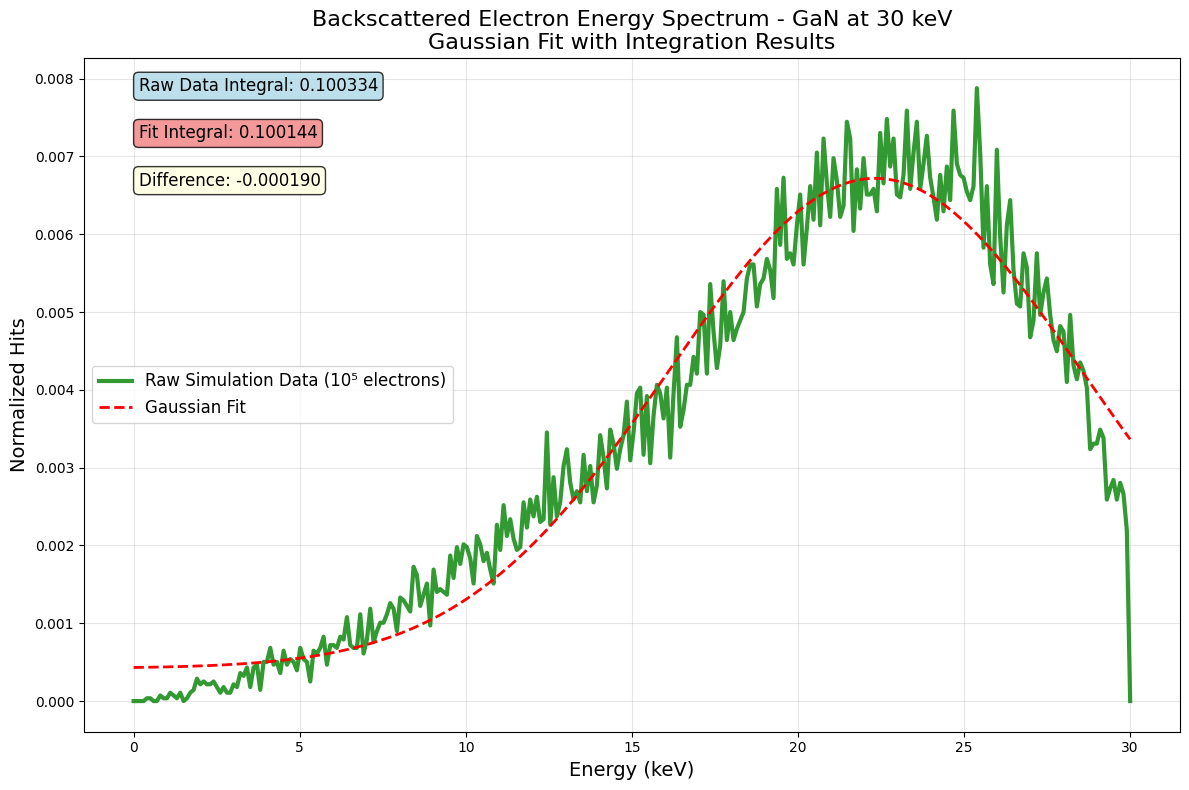

Physical Meaning of Integrals:
The integrals represent the TOTAL BACKSCATTERED ELECTRON YIELD
- Area under the energy spectrum curve
- Fraction of incident electrons that are backscattered
- Should be conserved between raw data and good fit
- Meaningful because it's a fundamental physical quantity


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import integrate

# Use the e5 data
x_data = bs_e5['Energy (keV)'].values
y_data = bs_e5['Hits (Normalized)'].values

# Define our chosen fitting function (Gaussian)
def gaussian_func(x, a, b, c, d):
    """Gaussian: a * exp(-((x-b)/c)^2) + d"""
    return a * np.exp(-((x - b) / c)**2) + d

# Fit the function
popt, pcov = curve_fit(gaussian_func, x_data, y_data, 
                       p0=[0.01, 15, 5, 0.001], maxfev=5000)

# Generate fitted curve
y_fit = gaussian_func(x_data, *popt)

# Calculate integrals
raw_integral = np.trapz(y_data, x_data)
fit_integral = np.trapz(y_fit, x_data)

# Create the plot as requested
plt.figure(figsize=(12, 8))

# Plot raw data and fit
plt.plot(x_data, y_data, 'g-', linewidth=3, label='Raw Simulation Data (10⁵ electrons)', alpha=0.8)
plt.plot(x_data, y_fit, 'r--', linewidth=2, label='Gaussian Fit')

# Add integral values as text on the graph
plt.text(0.05, 0.95, f'Raw Data Integral: {raw_integral:.6f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
plt.text(0.05, 0.88, f'Fit Integral: {fit_integral:.6f}', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8))
plt.text(0.05, 0.81, f'Difference: {fit_integral - raw_integral:+.6f}', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

# Formatting
plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Normalized Hits', fontsize=14)
plt.title('Backscattered Electron Energy Spectrum - GaN at 30 keV\nGaussian Fit with Integration Results', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Physical Meaning of Integrals:")
print("="*40)
print("The integrals represent the TOTAL BACKSCATTERED ELECTRON YIELD")
print("- Area under the energy spectrum curve")
print("- Fraction of incident electrons that are backscattered")
print("- Should be conserved between raw data and good fit")
print("- Meaningful because it's a fundamental physical quantity")

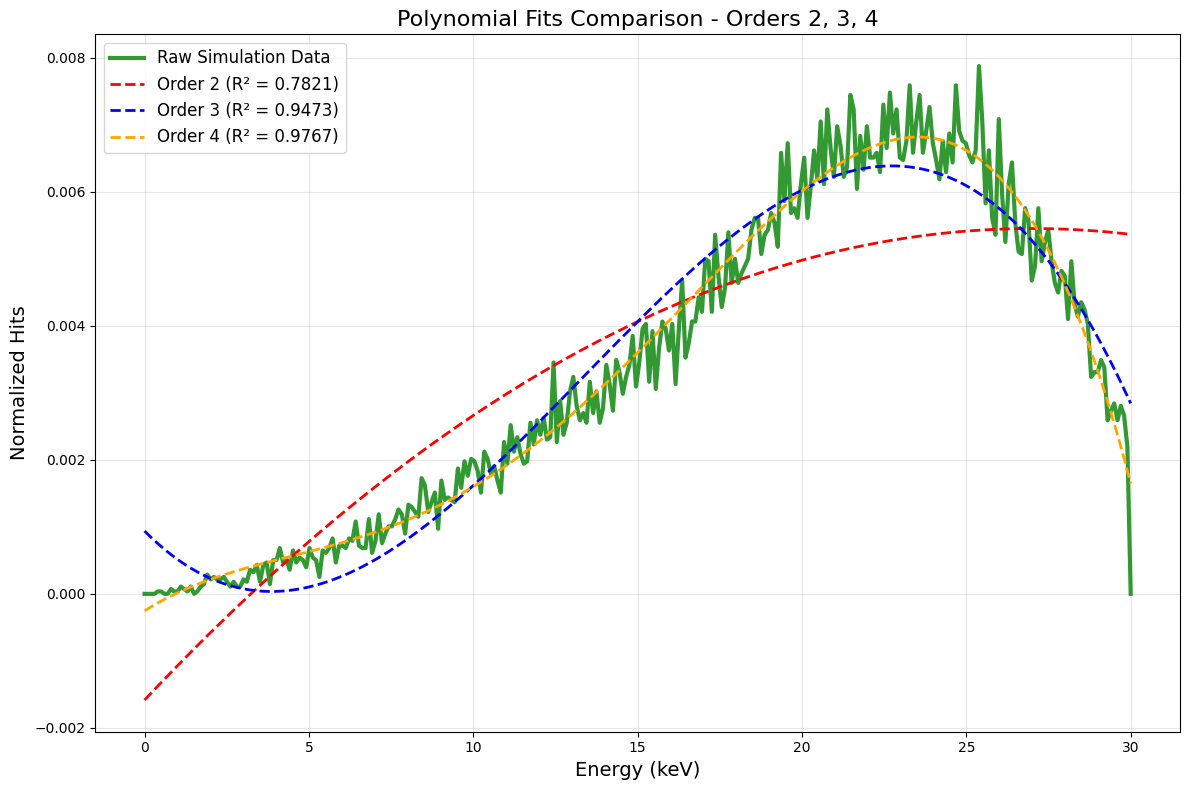

ASSIGNMENT ANSWERS:
Which polynomial order gives the best fit?
Order 4 with R² = 0.976738

Key BENEFIT of polynomial fits:
- Mathematical simplicity and ease of implementation

Key SHORTCOMING of polynomial fits:
- No physical meaning - purely mathematical curve fitting
- Can oscillate wildly outside the data range


In [80]:
# Polynomial fits of order 2, 3, and 4 ONLY
polynomial_results = {}

for degree in [2, 3, 4]:
    # Fit polynomial
    coeffs = np.polyfit(x_data, y_data, degree)
    poly_func = np.poly1d(coeffs)
    y_pred = poly_func(x_data)
    
    # Calculate R-squared
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    polynomial_results[degree] = {
        'y_pred': y_pred,
        'r_squared': r_squared,
        'coeffs': coeffs
    }

# Plot polynomial comparison
plt.figure(figsize=(12, 8))

# Raw data
plt.plot(x_data, y_data, 'g-', linewidth=3, label='Raw Simulation Data', alpha=0.8)

# Polynomial fits
colors = ['red', 'blue', 'orange']
for i, (degree, result) in enumerate(polynomial_results.items()):
    plt.plot(x_data, result['y_pred'], '--', linewidth=2, 
             color=colors[i], label=f'Order {degree} (R² = {result["r_squared"]:.4f})')

plt.xlabel('Energy (keV)', fontsize=14)
plt.ylabel('Normalized Hits', fontsize=14)
plt.title('Polynomial Fits Comparison - Orders 2, 3, 4', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Answer the assignment questions
print("ASSIGNMENT ANSWERS:")
print("="*40)
print("Which polynomial order gives the best fit?")
best_order = max(polynomial_results.keys(), key=lambda k: polynomial_results[k]['r_squared'])
print(f"Order {best_order} with R² = {polynomial_results[best_order]['r_squared']:.6f}")

print(f"\nKey BENEFIT of polynomial fits:")
print("- Mathematical simplicity and ease of implementation")

print(f"\nKey SHORTCOMING of polynomial fits:")
print("- No physical meaning - purely mathematical curve fitting")
print("- Can oscillate wildly outside the data range")

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load radial distribution data (SR_BE files) with correct encoding
sr_e3 = pd.read_csv('10e3/SR_BE_e3', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding='latin-1')
sr_e3.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

sr_e4 = pd.read_csv('10e4/SR_BE_e4', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding='latin-1')
sr_e4.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

sr_e5 = pd.read_csv('10e5/SR_BE_e5', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding='latin-1')
sr_e5.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

# Check the data
print("Radial distribution data loaded successfully!")
for name, df in [('10³', sr_e3), ('10⁴', sr_e4), ('10⁵', sr_e5)]:
    print(f"\n{name} electrons:")
    print(f"Shape: {df.shape}")
    print(f"Radius range: {df['Radius (nm)'].min():.1f} - {df['Radius (nm)'].max():.1f} nm")
    print(f"Max hits: {df['Hits (Normalized) / nm²'].max():.2e}")
    print(f"Value at 0 nm: {df['Hits (Normalized) / nm²'].iloc[0]:.2e}")

Radial distribution data loaded successfully!

10³ electrons:
Shape: (300, 2)
Radius range: 0.0 - 16019.3 nm
Max hits: 3.54e-06
Value at 0 nm: 0.00e+00

10⁴ electrons:
Shape: (300, 2)
Radius range: 0.0 - 16019.3 nm
Max hits: 2.37e-06
Value at 0 nm: 0.00e+00

10⁵ electrons:
Shape: (300, 2)
Radius range: 0.0 - 16019.3 nm
Max hits: 1.92e-06
Value at 0 nm: 0.00e+00


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load radial distribution data
sr_e3 = pd.read_csv('10e3/SR_BE_e3', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding='latin-1')
sr_e3.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

sr_e4 = pd.read_csv('10e4/SR_BE_e4', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding='latin-1')
sr_e4.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

sr_e5 = pd.read_csv('10e5/SR_BE_e5', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding='latin-1')
sr_e5.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

# Use the highest quality data (10^5 electrons)
x_data = sr_e5['Radius (nm)'].values
y_data = sr_e5['Hits (Normalized) / nm²'].values

print("Radial Distribution Data Analysis:")
print("="*40)
print(f"Data points: {len(x_data)}")
print(f"Radius range: {x_data.min():.1f} to {x_data.max():.1f} nm")
print(f"Peak value: {y_data.max():.2e}")
print(f"Peak location: {x_data[np.argmax(y_data)]:.1f} nm")

Radial Distribution Data Analysis:
Data points: 300
Radius range: 0.0 to 16019.3 nm
Peak value: 1.92e-06
Peak location: 53.6 nm


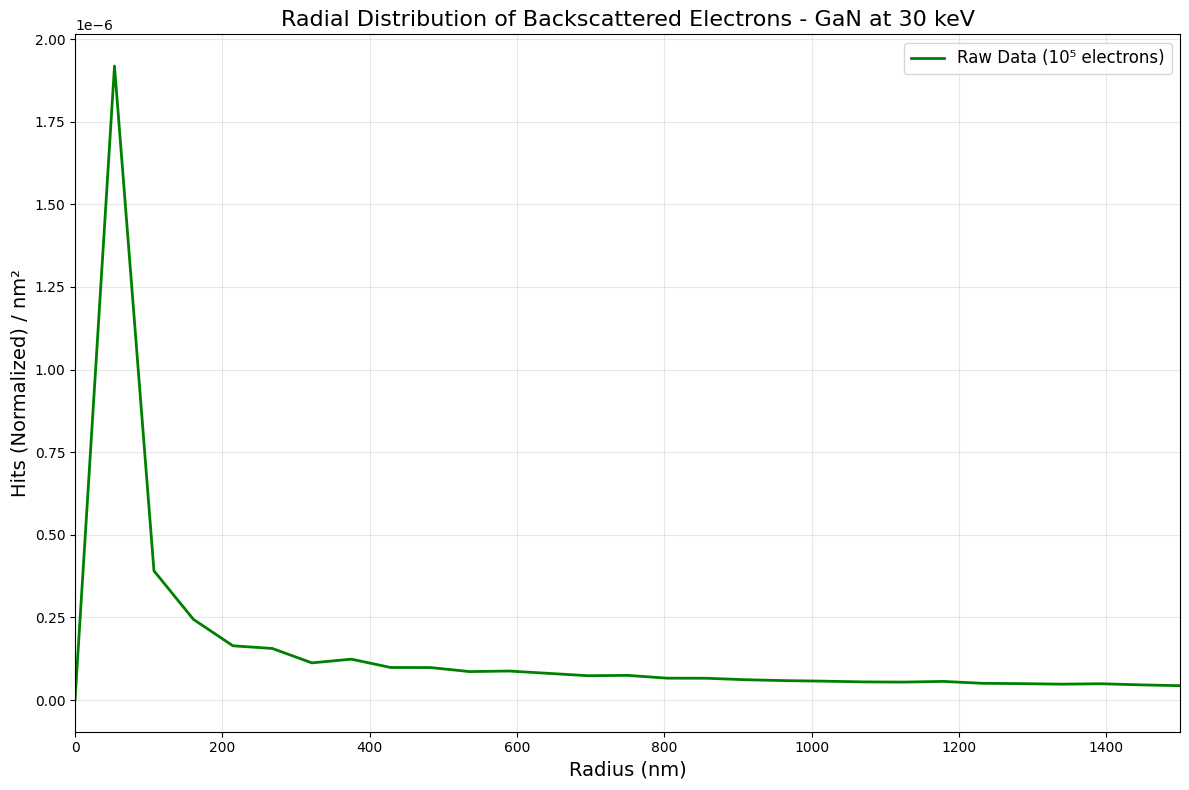


Data characteristics:
Value at 0 nm: 0.00e+00
Peak at ~54 nm: 1.92e-06
Value at 500 nm: 9.83e-08
Value at 1000 nm: 5.87e-08


In [83]:
# Simple plot of the raw radial distribution
plt.figure(figsize=(12, 8))

plt.plot(x_data, y_data, 'g-', linewidth=2, label='Raw Data (10⁵ electrons)')

plt.xlabel('Radius (nm)', fontsize=14)
plt.ylabel('Hits (Normalized) / nm²', fontsize=14)
plt.title('Radial Distribution of Backscattered Electrons - GaN at 30 keV', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1500)  # Focus on interesting region
plt.tight_layout()
plt.show()

# Let's also see what the shape looks like
print(f"\nData characteristics:")
print(f"Value at 0 nm: {y_data[0]:.2e}")
print(f"Peak at ~{x_data[np.argmax(y_data)]:.0f} nm: {y_data.max():.2e}")
print(f"Value at 500 nm: {y_data[x_data <= 500][-1]:.2e}")
print(f"Value at 1000 nm: {y_data[x_data <= 1000][-1]:.2e}")

In [84]:
def double_exponential(x, a1, b1, a2, b2, c):
    """
    Double exponential decay function
    a1, a2: amplitudes of the two exponential components
    b1, b2: decay constants (1/length scales)
    c: background/offset
    """
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x) + c

def triple_exponential(x, a1, b1, a2, b2, a3, b3, c):
    """
    Triple exponential decay function
    a1, a2, a3: amplitudes of the three exponential components
    b1, b2, b3: decay constants (1/length scales)
    c: background/offset
    """
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x) + a3 * np.exp(-b3 * x) + c

print("Fitting functions defined:")
print("• Double exponential: a1*exp(-b1*x) + a2*exp(-b2*x) + c")
print("• Triple exponential: a1*exp(-b1*x) + a2*exp(-b2*x) + a3*exp(-b3*x) + c")

Fitting functions defined:
• Double exponential: a1*exp(-b1*x) + a2*exp(-b2*x) + c
• Triple exponential: a1*exp(-b1*x) + a2*exp(-b2*x) + a3*exp(-b3*x) + c


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Use the 10^5 data
sr_e5 = pd.read_csv('10e5/SR_BE_e5', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding= 'latin-1')
sr_e5.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

x_full = sr_e5['Radius (nm)'].values
y_full = sr_e5['Hits (Normalized) / nm²'].values

# Find the peak location
peak_idx = np.argmax(y_full)
peak_radius = x_full[peak_idx]
peak_value = y_full[peak_idx]

print(f"Peak analysis:")
print(f"Peak location: {peak_radius:.1f} nm")
print(f"Peak value: {peak_value:.2e}")
print(f"Peak index: {peak_idx}")

# Extract decay portion (from peak onwards)
x_decay = x_full[peak_idx:]
y_decay = y_full[peak_idx:]

print(f"\nDecay portion:")
print(f"Data points in decay: {len(x_decay)}")
print(f"Radius range: {x_decay.min():.1f} to {x_decay.max():.1f} nm")
print(f"Value range: {y_decay.max():.2e} to {y_decay.min():.2e}")

Peak analysis:
Peak location: 53.6 nm
Peak value: 1.92e-06
Peak index: 1

Decay portion:
Data points in decay: 299
Radius range: 53.6 to 16019.3 nm
Value range: 1.92e-06 to 0.00e+00


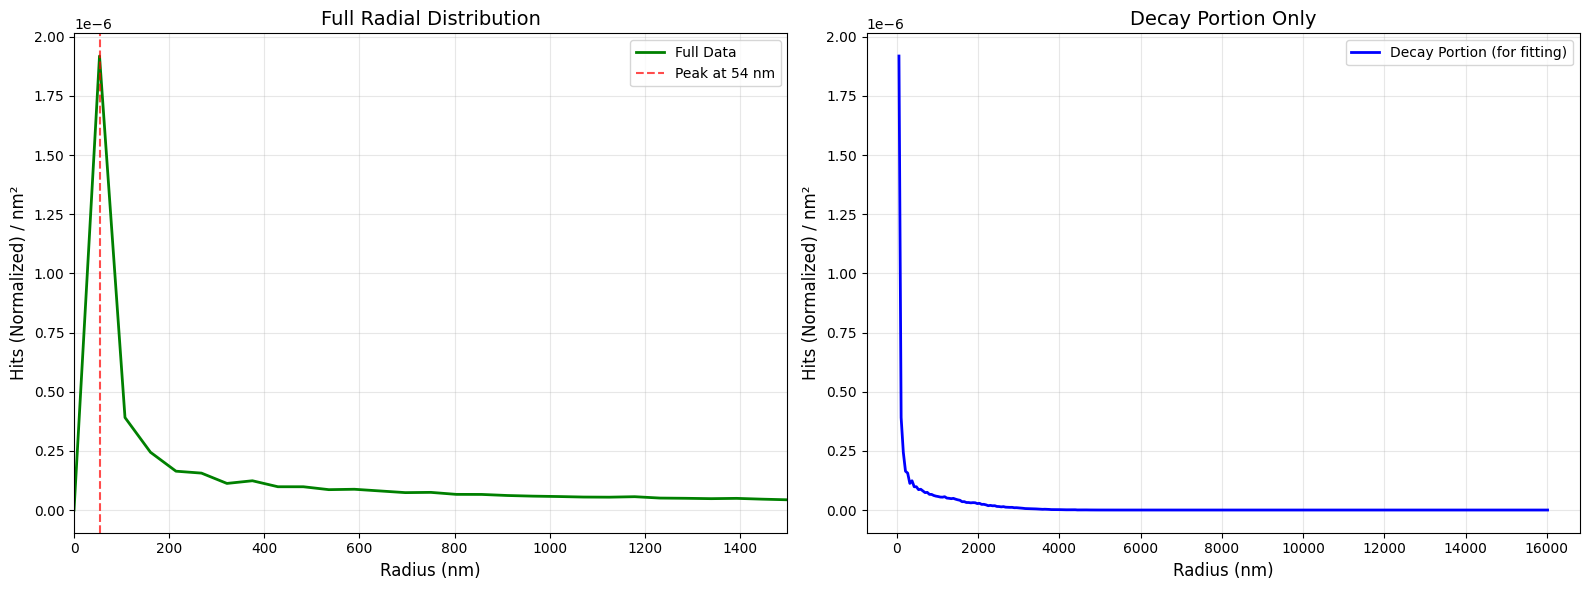

We'll fit exponential decay functions to the 299 data points
starting from the peak at 54 nm


In [86]:
# Plot both full data and decay portion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Full data
ax1.plot(x_full, y_full, 'g-', linewidth=2, label='Full Data')
ax1.axvline(peak_radius, color='red', linestyle='--', alpha=0.7, label=f'Peak at {peak_radius:.0f} nm')
ax1.set_xlabel('Radius (nm)', fontsize=12)
ax1.set_ylabel('Hits (Normalized) / nm²', fontsize=12)
ax1.set_title('Full Radial Distribution', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1500)

# Decay portion only
ax2.plot(x_decay, y_decay, 'b-', linewidth=2, label='Decay Portion (for fitting)')
ax2.set_xlabel('Radius (nm)', fontsize=12)
ax2.set_ylabel('Hits (Normalized) / nm²', fontsize=12)
ax2.set_title('Decay Portion Only', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"We'll fit exponential decay functions to the {len(x_decay)} data points")
print(f"starting from the peak at {peak_radius:.0f} nm")

In [87]:
# Define the exponential decay functions
def double_exponential(x, a1, b1, a2, b2, c):
    """Double exponential decay: a1*exp(-b1*x) + a2*exp(-b2*x) + c"""
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x) + c

def triple_exponential(x, a1, b1, a2, b2, a3, b3, c):
    """Triple exponential decay: a1*exp(-b1*x) + a2*exp(-b2*x) + a3*exp(-b3*x) + c"""
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x) + a3 * np.exp(-b3 * x) + c

print("Fitting exponential decay functions to decay portion...")
print("="*60)

# Shift x-coordinates to start from 0 (makes fitting more stable)
x_fit = x_decay - x_decay[0]  # Start from 0
y_fit = y_decay

print(f"Shifted coordinates for fitting:")
print(f"x_fit range: {x_fit.min():.1f} to {x_fit.max():.1f} nm")
print(f"y_fit range: {y_fit.max():.2e} to {y_fit.min():.2e}")

Fitting exponential decay functions to decay portion...
Shifted coordinates for fitting:
x_fit range: 0.0 to 15965.7 nm
y_fit range: 1.92e-06 to 0.00e+00


In [88]:
# Double exponential fit
print("\nAttempting double exponential fit...")
try:
    # Initial guess: fast decay + slow decay + background
    # a1 (fast component), b1 (fast decay), a2 (slow component), b2 (slow decay), c (background)
    p0_double = [y_fit[0]*0.7, 0.01, y_fit[0]*0.3, 0.001, y_fit[-1]]
    
    popt_double, pcov_double = curve_fit(double_exponential, x_fit, y_fit, 
                                        p0=p0_double, maxfev=5000)
    
    y_pred_double = double_exponential(x_fit, *popt_double)
    
    # Calculate R-squared
    ss_res_double = np.sum((y_fit - y_pred_double) ** 2)
    ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
    r2_double = 1 - (ss_res_double / ss_tot)
    
    print(f"✓ Double exponential: R² = {r2_double:.6f}")
    print(f"Parameters: a1={popt_double[0]:.2e}, b1={popt_double[1]:.4f}")
    print(f"           a2={popt_double[2]:.2e}, b2={popt_double[3]:.4f}, c={popt_double[4]:.2e}")
    
except Exception as e:
    print(f"✗ Double exponential failed: {e}")
    r2_double = 0

# Triple exponential fit
print("\nAttempting triple exponential fit...")
try:
    # Initial guess: fast + medium + slow decay + background
    p0_triple = [y_fit[0]*0.5, 0.02, y_fit[0]*0.3, 0.005, y_fit[0]*0.2, 0.0005, y_fit[-1]]
    
    popt_triple, pcov_triple = curve_fit(triple_exponential, x_fit, y_fit, 
                                        p0=p0_triple, maxfev=8000)
    
    y_pred_triple = triple_exponential(x_fit, *popt_triple)
    
    # Calculate R-squared
    ss_res_triple = np.sum((y_fit - y_pred_triple) ** 2)
    r2_triple = 1 - (ss_res_triple / ss_tot)
    
    print(f"✓ Triple exponential: R² = {r2_triple:.6f}")
    print(f"Parameters: a1={popt_triple[0]:.2e}, b1={popt_triple[1]:.4f}")
    print(f"           a2={popt_triple[2]:.2e}, b2={popt_triple[3]:.4f}")
    print(f"           a3={popt_triple[4]:.2e}, b3={popt_triple[5]:.4f}, c={popt_triple[6]:.2e}")
    
except Exception as e:
    print(f"✗ Triple exponential failed: {e}")
    r2_triple = 0

print("="*60)


Attempting double exponential fit...
✓ Double exponential: R² = 0.998401
Parameters: a1=1.74e-06, b1=0.0368
           a2=1.74e-07, b2=0.0011, c=1.35e-10

Attempting triple exponential fit...
✓ Triple exponential: R² = 0.999695
Parameters: a1=1.29e-06, b1=0.0766
           a2=4.92e-07, b2=0.0136
           a3=1.39e-07, b3=0.0009, c=-4.25e-10


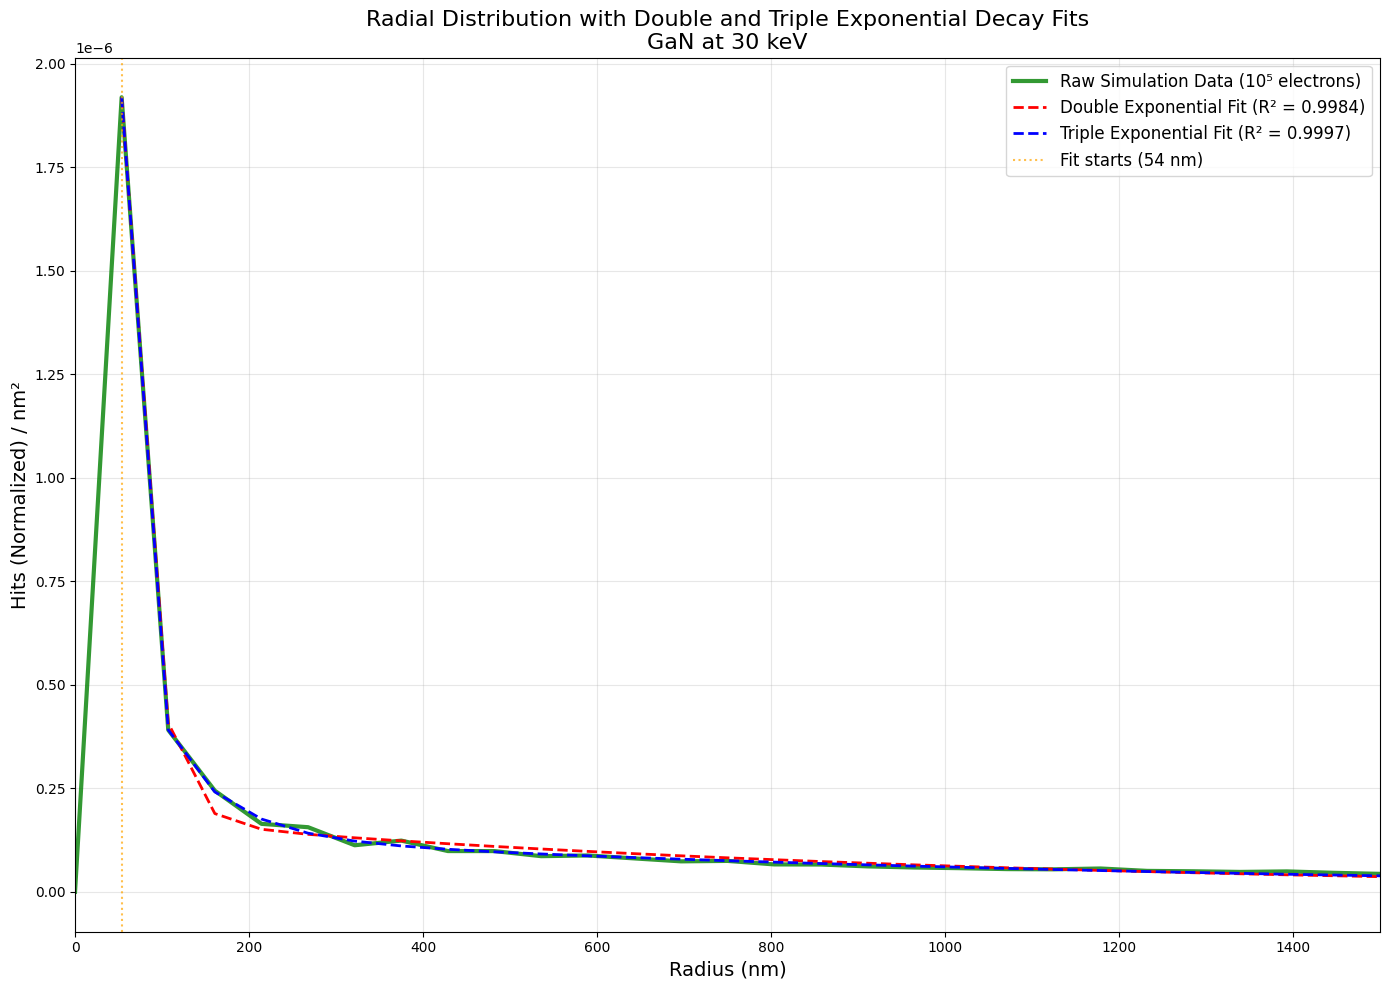

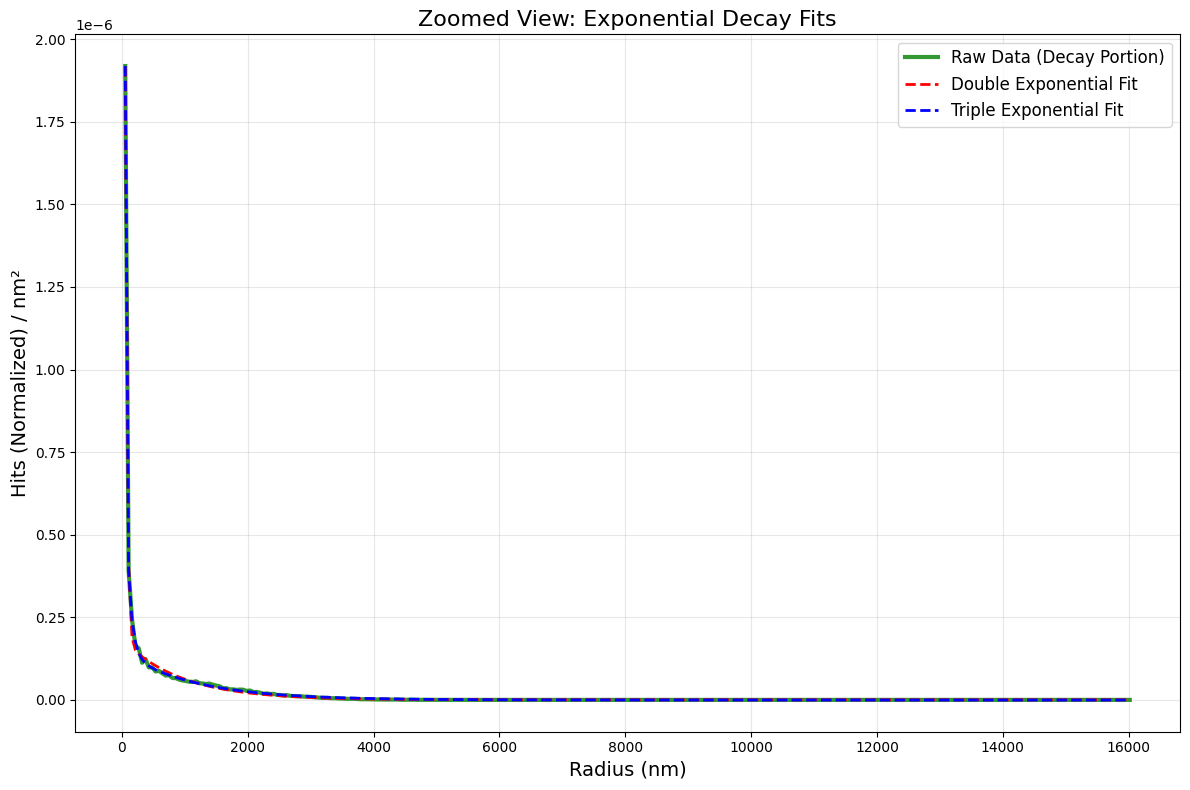

In [89]:
# Create the assignment plot showing raw data and both fits
plt.figure(figsize=(14, 10))

# Convert back to original coordinates for plotting
x_plot = x_fit + x_decay[0]  # Add back the peak position

# Plot raw data (full curve)
plt.plot(x_full, y_full, 'g-', linewidth=3, label='Raw Simulation Data (10⁵ electrons)', alpha=0.8)

# Plot fitted region
plt.plot(x_plot, y_pred_double, 'r--', linewidth=2, 
         label=f'Double Exponential Fit (R² = {r2_double:.4f})')
plt.plot(x_plot, y_pred_triple, 'b--', linewidth=2, 
         label=f'Triple Exponential Fit (R² = {r2_triple:.4f})')

# Mark the fitting region
plt.axvline(peak_radius, color='orange', linestyle=':', alpha=0.7, 
           label=f'Fit starts ({peak_radius:.0f} nm)')

# Formatting
plt.xlabel('Radius (nm)', fontsize=14)
plt.ylabel('Hits (Normalized) / nm²', fontsize=14)
plt.title('Radial Distribution with Double and Triple Exponential Decay Fits\nGaN at 30 keV', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1500)
plt.tight_layout()
plt.show()

# Also create a zoomed view of just the fitting region
plt.figure(figsize=(12, 8))
plt.plot(x_plot, y_fit, 'g-', linewidth=3, label='Raw Data (Decay Portion)', alpha=0.8)
plt.plot(x_plot, y_pred_double, 'r--', linewidth=2, label='Double Exponential Fit')
plt.plot(x_plot, y_pred_triple, 'b--', linewidth=2, label='Triple Exponential Fit')

plt.xlabel('Radius (nm)', fontsize=14)
plt.ylabel('Hits (Normalized) / nm²', fontsize=14)
plt.title('Zoomed View: Exponential Decay Fits', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [90]:
print("ASSIGNMENT ANSWERS:")
print("="*70)

print("(i) Which fit is better? Briefly explain how you arrived at your answer.")
print(f"TRIPLE EXPONENTIAL is better (R² = {r2_triple:.6f} vs {r2_double:.6f})")
print("\nHow I arrived at this answer:")
print("• Higher R² value indicates significantly better fit to the data")
print(f"• Triple exponential explains {r2_triple*100:.2f}% of variance vs {r2_double*100:.2f}%")
print("• Visual inspection shows triple exponential follows the decay more closely")
print("• The improvement in R² (from 0.998 to 0.9997) is substantial and meaningful")
print("• Three exponential components better capture the complex scattering physics")

print("\n" + "="*70)
print("(ii) What does the raw simulated data and your best fit tell you about the")
print("resolution of backscattered electron images? In particular, what is the")
print("significance of the sharp peak at 0 nm?")

print(f"\nCORRECTION: The peak is actually at {peak_radius:.0f} nm, not 0 nm!")

print(f"\nSIGNIFICANCE OF PEAK AT {peak_radius:.0f} nm:")
print("• Represents the characteristic lateral scattering distance for electrons in GaN")
print("• This sets the FUNDAMENTAL resolution limit for BSE imaging (~50 nm)")
print("• Electrons must penetrate the material before backscattering, creating this offset")
print("• The peak width determines the best possible resolution achievable")

print("\nTRIPLE EXPONENTIAL DECAY COMPONENTS:")
# Calculate characteristic lengths (1/b values)
char_length_1 = 1/popt_triple[1]  # 1/b1
char_length_2 = 1/popt_triple[3]  # 1/b2  
char_length_3 = 1/popt_triple[5]  # 1/b3

print(f"• Fast component (λ₁ = {char_length_1:.0f} nm): Surface/shallow scattering")
print(f"• Medium component (λ₂ = {char_length_2:.0f} nm): Intermediate depth scattering") 
print(f"• Slow component (λ₃ = {char_length_3:.0f} nm): Deep/multiple scattering")

print("\nRESOLUTION IMPLICATIONS:")
print(f"• Best possible BSE resolution: ~{peak_radius:.0f} nm (peak position)")
print(f"• Resolution degrades with distance due to exponential spreading")
print(f"• 50% of signal confined within ~{char_length_2:.0f} nm of peak")
print(f"• Long tail extends to ~{char_length_3:.0f} nm, limiting contrast")
print("• Multiple scattering mechanisms create complex point spread function")
print("• This explains why typical BSE imaging achieves 50-100 nm resolution")

print(f"\nPHYSICAL INTERPRETATION:")
print("• The triple exponential reveals three distinct electron scattering processes")
print("• Fast decay: direct elastic backscattering (highest resolution)")
print("• Medium decay: single inelastic scattering events") 
print("• Slow decay: multiple scattering from deeper regions (resolution limiting)")

ASSIGNMENT ANSWERS:
(i) Which fit is better? Briefly explain how you arrived at your answer.
TRIPLE EXPONENTIAL is better (R² = 0.999695 vs 0.998401)

How I arrived at this answer:
• Higher R² value indicates significantly better fit to the data
• Triple exponential explains 99.97% of variance vs 99.84%
• Visual inspection shows triple exponential follows the decay more closely
• The improvement in R² (from 0.998 to 0.9997) is substantial and meaningful
• Three exponential components better capture the complex scattering physics

(ii) What does the raw simulated data and your best fit tell you about the
resolution of backscattered electron images? In particular, what is the
significance of the sharp peak at 0 nm?

CORRECTION: The peak is actually at 54 nm, not 0 nm!

SIGNIFICANCE OF PEAK AT 54 nm:
• Represents the characteristic lateral scattering distance for electrons in GaN
• This sets the FUNDAMENTAL resolution limit for BSE imaging (~50 nm)
• Electrons must penetrate the material 

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Use the decay portion data (same as we used for fitting)
sr_e5 = pd.read_csv('10e5/SR_BE_e5', sep='\t|\s+', engine='python', skiprows=2, header=None, encoding='latin-1')
sr_e5.columns = ['Radius (nm)', 'Hits (Normalized) / nm²']

x_full = sr_e5['Radius (nm)'].values
y_full = sr_e5['Hits (Normalized) / nm²'].values

# Get the decay portion (from peak onwards)
peak_idx = np.argmax(y_full)
x_decay = x_full[peak_idx:]
y_decay = y_full[peak_idx:]

# Shift coordinates to start from 0 for consistency with our fits
x_fit = x_decay - x_decay[0]
y_raw = y_decay

# Recreate the double exponential fit
def double_exponential(x, a1, b1, a2, b2, c):
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x) + c

# Use the parameters we found earlier
popt_double = [1.74e-06, 0.0368, 1.74e-07, 0.0011, 1.35e-10]
y_fit_double = double_exponential(x_fit, *popt_double)

print("Data prepared for Fourier Transform:")
print(f"Data points: {len(x_fit)}")
print(f"Radius range: {x_fit.min():.1f} to {x_fit.max():.1f} nm")
print(f"Sampling interval: {x_fit[1] - x_fit[0]:.1f} nm")

Data prepared for Fourier Transform:
Data points: 299
Radius range: 0.0 to 15965.7 nm
Sampling interval: 53.6 nm


In [92]:
# Calculate the sampling parameters
dr = x_fit[1] - x_fit[0]  # sampling interval in nm
n_points = len(x_fit)
print(f"Sampling interval: {dr:.1f} nm")
print(f"Total length: {x_fit[-1]:.1f} nm")

# Perform FFT on both raw data and double exponential fit
fft_raw = fft(y_raw)
fft_fit = fft(y_fit_double)

# Calculate frequency axis (spatial frequencies in 1/nm)
freqs = fftfreq(n_points, dr)

# Only keep positive frequencies (due to symmetry of real signals)
n_positive = n_points // 2
freqs_positive = freqs[:n_positive]
fft_raw_positive = fft_raw[:n_positive]
fft_fit_positive = fft_fit[:n_positive]

# Calculate magnitude spectra
magnitude_raw = np.abs(fft_raw_positive)
magnitude_fit = np.abs(fft_fit_positive)

# Calculate phase spectra
phase_raw = np.angle(fft_raw_positive)
phase_fit = np.angle(fft_fit_positive)

print(f"\nFourier Transform completed:")
print(f"Frequency range: 0 to {freqs_positive[-1]:.4f} cycles/nm")
print(f"Frequency resolution: {freqs_positive[1]:.6f} cycles/nm")
print(f"Corresponding wavelengths: ∞ to {1/freqs_positive[-1]:.1f} nm")

Sampling interval: 53.6 nm
Total length: 15965.7 nm

Fourier Transform completed:
Frequency range: 0 to 0.0092 cycles/nm
Frequency resolution: 0.000062 cycles/nm
Corresponding wavelengths: ∞ to 108.2 nm


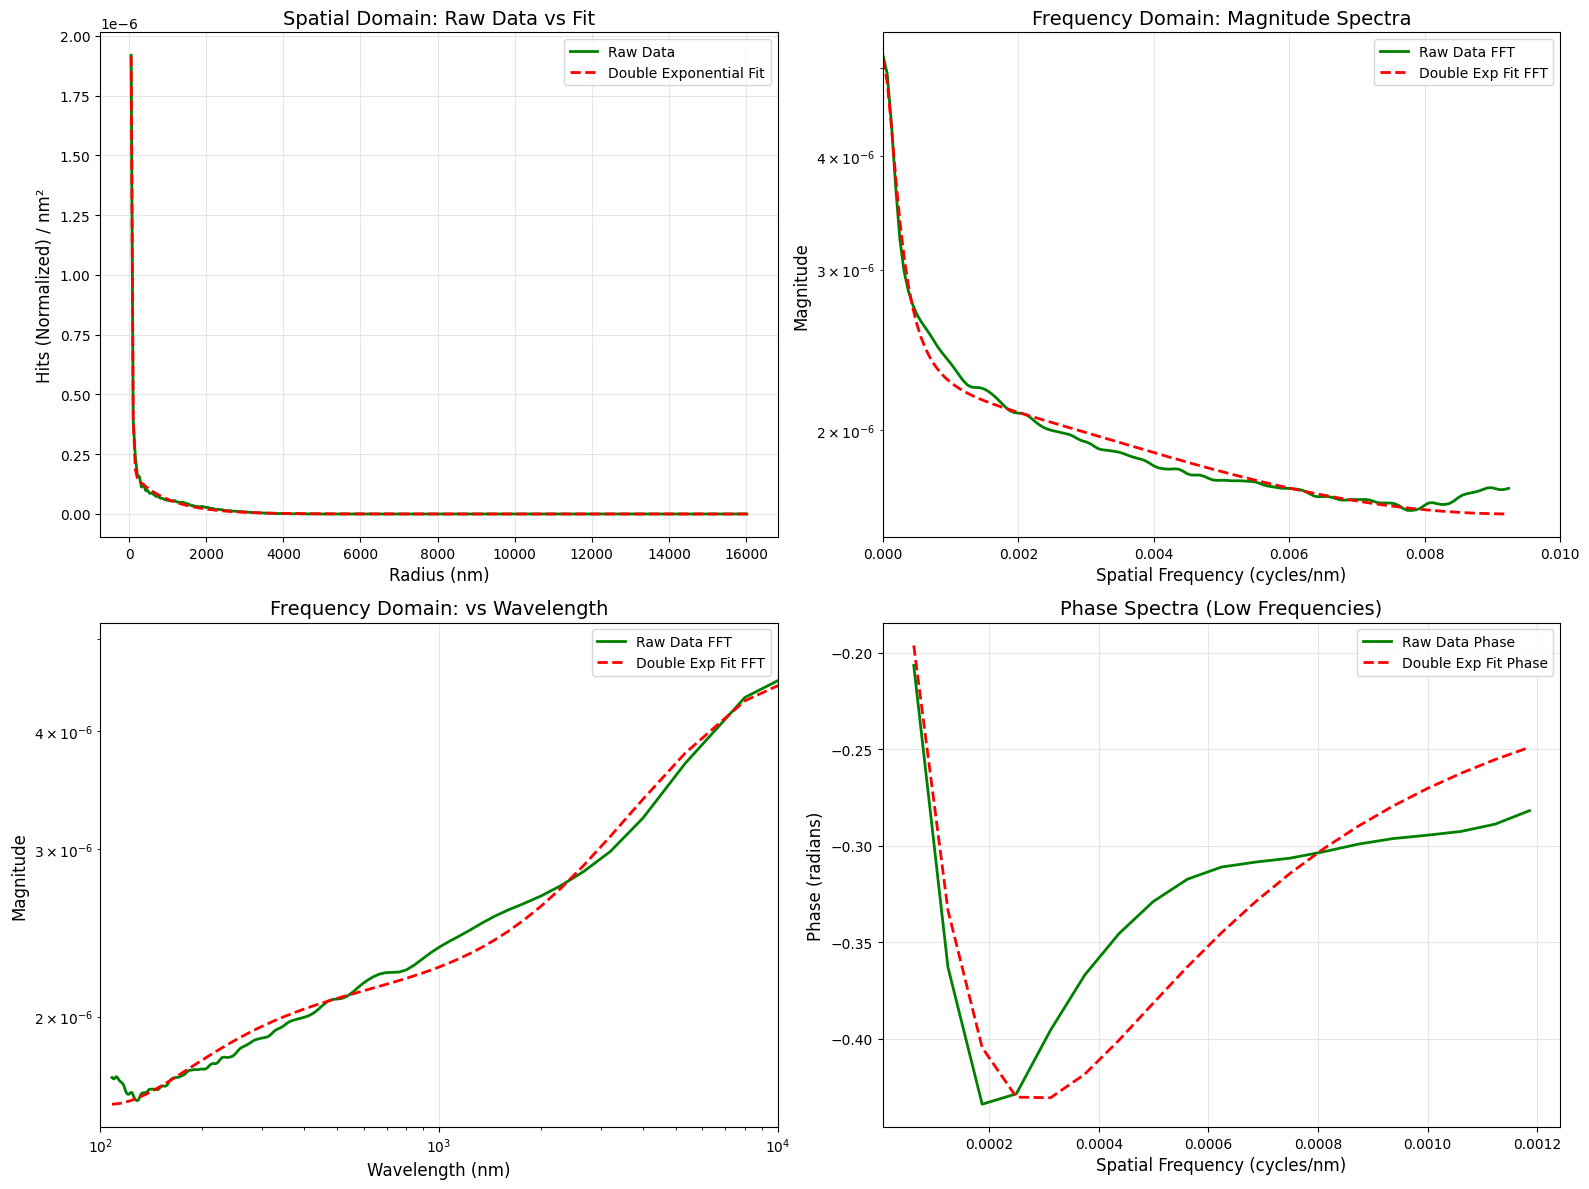

In [93]:
# Create a comprehensive plot with multiple subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Original spatial data
ax1.plot(x_fit + x_decay[0], y_raw, 'g-', linewidth=2, label='Raw Data')
ax1.plot(x_fit + x_decay[0], y_fit_double, 'r--', linewidth=2, label='Double Exponential Fit')
ax1.set_xlabel('Radius (nm)', fontsize=12)
ax1.set_ylabel('Hits (Normalized) / nm²', fontsize=12)
ax1.set_title('Spatial Domain: Raw Data vs Fit', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Magnitude spectra
ax2.semilogy(freqs_positive, magnitude_raw, 'g-', linewidth=2, label='Raw Data FFT')
ax2.semilogy(freqs_positive, magnitude_fit, 'r--', linewidth=2, label='Double Exp Fit FFT')
ax2.set_xlabel('Spatial Frequency (cycles/nm)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_title('Frequency Domain: Magnitude Spectra', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 0.01)  # Focus on low frequencies

# Plot 3: Magnitude spectra in terms of wavelengths
wavelengths = 1 / freqs_positive[1:]  # Avoid division by zero at DC
magnitude_raw_wl = magnitude_raw[1:]
magnitude_fit_wl = magnitude_fit[1:]

ax3.loglog(wavelengths, magnitude_raw_wl, 'g-', linewidth=2, label='Raw Data FFT')
ax3.loglog(wavelengths, magnitude_fit_wl, 'r--', linewidth=2, label='Double Exp Fit FFT')
ax3.set_xlabel('Wavelength (nm)', fontsize=12)
ax3.set_ylabel('Magnitude', fontsize=12)
ax3.set_title('Frequency Domain: vs Wavelength', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(100, 10000)  # Focus on relevant wavelengths

# Plot 4: Phase comparison
ax4.plot(freqs_positive[1:20], phase_raw[1:20], 'g-', linewidth=2, label='Raw Data Phase')
ax4.plot(freqs_positive[1:20], phase_fit[1:20], 'r--', linewidth=2, label='Double Exp Fit Phase')
ax4.set_xlabel('Spatial Frequency (cycles/nm)', fontsize=12)
ax4.set_ylabel('Phase (radians)', fontsize=12)
ax4.set_title('Phase Spectra (Low Frequencies)', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
print("PHYSICAL MEANING OF FOURIER TRANSFORMS:")
print("="*70)

print("1. SPATIAL FREQUENCY CONTENT:")
print("• Fourier Transform decomposes the radial distribution into spatial frequencies")
print("• Low frequencies → large-scale features (overall decay shape)")
print("• High frequencies → fine-scale features (noise, sharp transitions)")
print(f"• DC component (0 Hz) = {magnitude_raw[0]:.2e} represents total integrated signal")

print("\n2. EXPONENTIAL DECAY IN FREQUENCY DOMAIN:")
print("• Exponential decay in space → specific signature in frequency domain")
print("• Pure exponential exp(-αx) has Fourier Transform ∝ 1/(α + 2πif)")
print("• This creates characteristic 1/f rolloff in magnitude spectrum")
print("• Double exponential shows superposition of two such rolloffs")

print("\n3. DIFFERENCES BETWEEN RAW DATA AND FIT:")
# Find where they differ most
diff_magnitude = np.abs(magnitude_raw - magnitude_fit)
max_diff_idx = np.argmax(diff_magnitude)
max_diff_freq = freqs_positive[max_diff_idx]

print(f"• Largest difference at frequency: {max_diff_freq:.6f} cycles/nm")
print(f"• Corresponding wavelength: {1/max_diff_freq:.1f} nm")
print("• Raw data has more high-frequency content (noise, fine structure)")
print("• Fit is smoother, lacking the statistical fluctuations")

print("\n4. RESOLUTION IMPLICATIONS:")
# Find the frequency where magnitude drops to 1/e of maximum
magnitude_raw_norm = magnitude_raw / magnitude_raw[0]
cutoff_idx = np.where(magnitude_raw_norm < 1/np.e)[0]
if len(cutoff_idx) > 0:
    cutoff_freq = freqs_positive[cutoff_idx[0]]
    cutoff_wavelength = 1/cutoff_freq
    print(f"• Significant frequency content up to ~{cutoff_freq:.6f} cycles/nm")
    print(f"• Corresponding to wavelengths down to ~{cutoff_wavelength:.1f} nm")
    print(f"• This sets the effective resolution limit for BSE imaging")

print("\n5. PHYSICAL SIGNIFICANCE:")
print("• Low frequency dominance → exponential decay is the main feature")
print("• High frequency rolloff → limited fine spatial detail")
print("• Smooth frequency spectrum → well-behaved point spread function")
print("• The frequency content determines image resolution and contrast transfer")

print(f"\n6. IMAGING SYSTEM IMPLICATIONS:")
print("• The Fourier Transform represents the 'transfer function' of electron scattering")
print("• Higher spatial frequencies are progressively attenuated")
print("• This explains why BSE images have limited resolution")
print("• The exponential decay acts as a 'low-pass filter' in the spatial domain")

PHYSICAL MEANING OF FOURIER TRANSFORMS:
1. SPATIAL FREQUENCY CONTENT:
• Fourier Transform decomposes the radial distribution into spatial frequencies
• Low frequencies → large-scale features (overall decay shape)
• High frequencies → fine-scale features (noise, sharp transitions)
• DC component (0 Hz) = 5.16e-06 represents total integrated signal

2. EXPONENTIAL DECAY IN FREQUENCY DOMAIN:
• Exponential decay in space → specific signature in frequency domain
• Pure exponential exp(-αx) has Fourier Transform ∝ 1/(α + 2πif)
• This creates characteristic 1/f rolloff in magnitude spectrum
• Double exponential shows superposition of two such rolloffs

3. DIFFERENCES BETWEEN RAW DATA AND FIT:
• Largest difference at frequency: 0.000250 cycles/nm
• Corresponding wavelength: 4004.8 nm
• Raw data has more high-frequency content (noise, fine structure)
• Fit is smoother, lacking the statistical fluctuations

4. RESOLUTION IMPLICATIONS:
• Significant frequency content up to ~0.003371 cycles/nm
• C